# Phase 15 — LoRA Variants: Accuracy and Privacy Comparison

**Thesis:** Code Division Modulation Layers Against Forgetting and Inference in Continual Gait Identification  
**Reference:** Milani, S. — University of Padova

---

## Overview

This notebook introduces **Low-Rank Adaptation (LoRA)** as a per-task parameter-efficient adapter  
and evaluates it against the existing CDML and WGR-CDML baselines along **two orthogonal axes**:

- **Continual Learning accuracy** — forgetting matrices, average accuracy, Task-1 retention
- **Privacy robustness** — three attacks following the Phase 11 threat model

### Models compared

| # | Model | Anti-forgetting | Privacy mechanism | LoRA |
|---|---|---|---|---|
| 1 | **CDML** | Sequence modulation (no replay) | Per-task seed | ✗ |
| 2 | **CDML + LoRA** | Sequence modulation + frozen backbone | Per-task seed + frozen base weights | ✓ |
| 3 | **WGR-CDML** | Sequence modulation + wavelet synthetic replay | Per-task seed + no raw data stored | ✗ |
| 4 | **WGR-CDML + LoRA** | Sequence modulation + wavelet replay + frozen backbone | Per-task seed + frozen base + no raw data | ✓ |

### LoRA design for continual learning

```
Task 1:  Full model trained  →  backbone weights W frozen
Task k>1: Only LoRA adapters (Aₖ, Bₖ) updated
          Forward: W·x  +  (Bₖ·Aₖ)·x × (α/r)
```

**Privacy hypothesis:** The frozen backbone W captures only coarse gait features shared  
across all tasks. Task-specific information is confined to small LoRA adapters (r×d  
parameters vs d×d full weights). Combined with CDML scrambling, this further limits  
what an attacker can infer from the model weights.

### Attacks

| Attack | Type | CDML attacker modes |
|---|---|---|
| **A — Identity Inference (IIA)** | Score-based MIA, black-box | no-seed (realistic) + oracle |
| **B — Feature Space Inference** | k-NN on embeddings, white-box | no-seed + oracle |
| **C — Backdoor / Trojan** | Sinusoidal trigger, poisoning | no-seed + oracle |

---

# Explanation on the architecture 

The matrices A and B used in the embedding layer are not the same as the ones used in the classifier. They are entirely separate matrices with different dimensions, and they are dynamically redefined for every new task.
Here is exactly how they are structured and when they are defined in the code:
1. Are they the same matrices?
They are distinct. The model (GaitCNN_LoRA) initializes two completely separate instances of the LoRALinear module:
The Embedding LoRA: * Base Weight (W): Maps the flattened output of the CNN (e.g., 512 dimensions) down to the 128-dimensional embedding.
Adapters (A 
embed
​	
 , B 
embed
​	
 ): Compress the 512 dimensions down to the bottleneck rank (e.g., r=8) and back up to 128.
The Classifier LoRA:
Base Weight (W): Maps the 128-dimensional scrambled embedding to the 118 output identity classes.
Adapters (A 
class
​	
 , B 
class
​	
 ): Compress the 128 dimensions down to the bottleneck rank (r=8) and back up to 118.
Both sets of adapters operate at the exact same time during the forward pass, but they transform data at different stages of the pipeline.
1. When are they defined and updated?
The lifecycle of the A and B matrices is explicitly tied to the Continual Learning process (learning Task 1, then Task 2, etc.). They are managed as follows:
Initial Creation (Task 1): When the model is first initialized, the adapter matrices A and B are created. A is initialized with random Kaiming uniform values, and B is initialized as entirely zeros. During Task 1, the model trains both the base weights (W) and the adapters.
Freezing the Base (End of Task 1): After Task 1 is complete, a function called freeze_base_weights() is triggered. This permanently locks the CNN backbone and the massive W base matrices in both the embedding and classifier layers.
Saving (End of Every Task): After any task finishes, the model calls save_lora(task_name). This takes the currently trained A and B matrices for both layers and saves a copy of them in a dictionary (_lora_states) linked to that task's name (e.g., "Task_1_Weights").
Resetting (Start of a New Task): When Task 2 begins, the model calls reset_lora(). This wipes the active A and B adapters back to their initial state (random for A, zeros for B). Because the base weights are frozen, only these tiny new A and B matrices are updated when learning Task 2.
Inference / Swapping: If you want to evaluate how the model performs on Task 1 while currently training on Task 3, the model calls load_lora("Task 1"). This temporarily loads Task 1's saved A and B matrices back into the network, runs the prediction, and then swaps back to the current task's adapters.

## 0. Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import (
    DataLoader, TensorDataset, random_split, ConcatDataset, Subset
)
from sklearn.metrics import roc_curve, auc as sk_auc
from sklearn.neighbors import KNeighborsClassifier
from copy import deepcopy
import warnings
warnings.filterwarnings('ignore')

try:
    import pywt
    PYWT_AVAILABLE = True
    print('PyWavelets available — DWT decomposition enabled')
except ImportError:
    PYWT_AVAILABLE = False
    print('PyWavelets not found — using FFT fallback for WGR')

plt.rcParams.update({
    'figure.dpi': 120, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.3, 'font.size': 11,
})

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')
print(f'Device: {DEVICE}  |  PyTorch: {torch.__version__}')

PyWavelets available — DWT decomposition enabled
Device: mps  |  PyTorch: 2.8.0


## 1. Configuration

In [ ]:
# ── Dataset path ─────────────────────────────────────────────────────────────
# Expected structure under DATA_DIR:
#   raw/phone/accel/data_16XX_accel_phone.txt
#   raw/phone/gyro/data_16XX_gyro_phone.txt
DATA_DIR = "../Data/wisdm-dataset"

# ── Sensor / window settings ──────────────────────────────────────────────────
N_CHANNELS      = 6    # phone-accel (x,y,z) + phone-gyro (x,y,z)
WINDOW_SIZE     = 200  # 10 s × 20 Hz = 200 samples
VAL_SPLIT       = 0.15
RANDOM_SEED     = 27
BATCH_SIZE      = 64
EMBED_DIM       = 128
N_CLASSES_TOTAL = 51   # 51 subjects (1600–1650, re-indexed 1–51)
CDML_SEED_BASE  = 1000

EPOCHS   = 100   # 100 = fast iteration | 400 = paper-accurate
LR_INIT  = 1e-3
LR_DECAY = 0.98

# 51 subjects split roughly equally across 4 tasks
TASK_SPLITS = {
    'Task 1': (1,  13),   # subjects  1–13
    'Task 2': (40, 51),   # subjects 14–26
    'Task 3': (27, 39),   # subjects 27–39
    'Task 4': (14, 26),   # subjects 40–51
}

# ── Model hyperparameters ─────────────────────────────────────────────────────
STD_REPLAY_FRAC  = 0.15   # Std 15% model

# CDML+KD (focal distillation)
KD_LAMBDA        = 0.001
KD_ALPHA         = 0.0    # focal: 0 = only penalise correct-sample divergence
KD_BETA          = 1.0
KD_MEMORY_FRAC   = 0.20

# WGR-CDML (Wavelet Generative Replay)
WGR_WAVELET      = 'db4'
WGR_LEVEL        = 3
WGR_N_SYNTH      = 30
WGR_JITTER_STD   = 0.05

# LiDER (Lipschitz-Driven Experience Replay)
LIDER_REPLAY_FRAC = 0.10
LIDER_WEIGHT      = 0.01
LIDER_KAPPA       = 2.0

# ── Attack A — IIA ────────────────────────────────────────────────────────────
IIA_N_QUERIES    = 20
IIA_AGGREGATION  = 'mean'

# ── Attack B — Feature Space Inference ───────────────────────────────────────
KNN_K            = 5

# ── Attack C — Backdoor ───────────────────────────────────────────────────────
# 0-indexed label for a Task 4 subject (subject 45 → re-indexed ID 45 → label idx 44)
BACKDOOR_TARGET_IDX  = 44
BACKDOOR_POISON_FRAC = 0.15
BACKDOOR_TRIGGER_AMP = 0.5
BACKDOOR_TRIGGER_FREQ = 8
BACKDOOR_TRIGGER_CH  = 2     # acc_z channel

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
print('Configuration set.')


# ── LoRA hyperparameters ──────────────────────────────────────────────────────
LORA_RANK      = 8     # rank r; try 4 / 8 / 16
LORA_ALPHA     = 8    # scaling alpha; scaling factor = alpha/rank = 1.0



Configuration set.


## 2. Data loading

In [3]:
import os

# ─────────────────────────────────────────────────────────────────────────────
# Helper: read one sensor directory (phone/accel or phone/gyro)
# Each file:  subject_id, activity_code, timestamp, x, y, z;
# ─────────────────────────────────────────────────────────────────────────────
def load_wisdm_sensor(data_dir, sensor_type):
    """Read all per-subject raw files for one phone sensor.

    Returns
    -------
    dict: {subject_id (int) -> {'activity': list[str], 'x': list, 'y': list, 'z': list}}
    """
    subdir = os.path.join(data_dir, 'raw', 'phone', sensor_type)
    sensor_data = {}
    for fname in sorted(os.listdir(subdir)):
        if not fname.endswith('.txt'):
            continue
        # filename pattern: data_16XX_accel_phone.txt
        subj_id = int(fname.split('_')[1])
        rows = {'activity': [], 'x': [], 'y': [], 'z': []}
        with open(os.path.join(subdir, fname)) as fh:
            for line in fh:
                line = line.strip().rstrip(';').strip()
                if not line:
                    continue
                parts = line.split(',')
                if len(parts) < 6:
                    continue
                try:
                    rows['activity'].append(parts[1].strip())
                    rows['x'].append(float(parts[3]))
                    rows['y'].append(float(parts[4]))
                    rows['z'].append(float(parts[5]))
                except (ValueError, IndexError):
                    pass   # skip malformed lines
        sensor_data[subj_id] = rows
    return sensor_data


def load_wisdm_walking(data_dir, window_size=200):
    """Load non-overlapping walking windows from WISDM phone accel + gyro.

    WISDM subjects 1600–1650 are re-indexed to 1–51 so that TASK_SPLITS
    (which reference IDs 1–51) work without modification.

    Returns
    -------
    X        : np.ndarray  shape (N, 6, window_size)  — channels: ax,ay,az,gx,gy,gz
    subjects : np.ndarray  shape (N,)                 — re-indexed subject IDs 1–51
    """
    print('Loading WISDM phone-accel...')
    accel = load_wisdm_sensor(data_dir, 'accel')
    print('Loading WISDM phone-gyro...')
    gyro  = load_wisdm_sensor(data_dir, 'gyro')

    # Intersect subjects present in both sensors and sort for stable re-indexing
    common_ids = sorted(set(accel.keys()) & set(gyro.keys()))
    reindex    = {sid: i + 1 for i, sid in enumerate(common_ids)}  # 1600→1, …, 1650→51
    print(f'Subjects found: {len(common_ids)}  ({common_ids[0]}–{common_ids[-1]})')

    X_list, subj_list = [], []

    for sid in common_ids:
        a = accel[sid]
        g = gyro[sid]

        # Extract contiguous walking (activity == 'A') readings
        a_xyz = [(x, y, z) for act, x, y, z
                 in zip(a['activity'], a['x'], a['y'], a['z']) if act == 'A']
        g_xyz = [(x, y, z) for act, x, y, z
                 in zip(g['activity'], g['x'], g['y'], g['z']) if act == 'A']

        if not a_xyz or not g_xyz:
            print(f'  WARNING: no walking data for subject {sid}, skipping.')
            continue

        # Trim to the shorter of the two sensor streams, then window
        min_len   = min(len(a_xyz), len(g_xyz))
        n_windows = min_len // window_size
        if n_windows == 0:
            print(f'  WARNING: subject {sid} has <{window_size} walking samples, skipping.')
            continue

        ax = [v[0] for v in a_xyz[:n_windows * window_size]]
        ay = [v[1] for v in a_xyz[:n_windows * window_size]]
        az = [v[2] for v in a_xyz[:n_windows * window_size]]
        gx = [v[0] for v in g_xyz[:n_windows * window_size]]
        gy = [v[1] for v in g_xyz[:n_windows * window_size]]
        gz = [v[2] for v in g_xyz[:n_windows * window_size]]

        for i in range(n_windows):
            s, e = i * window_size, (i + 1) * window_size
            window = np.array([
                ax[s:e], ay[s:e], az[s:e],   # accel channels 0-2
                gx[s:e], gy[s:e], gz[s:e],   # gyro  channels 3-5
            ], dtype=np.float32)              # shape (6, 200)
            X_list.append(window)
            subj_list.append(reindex[sid])

    X        = np.stack(X_list)            # (N, 6, 200)
    subjects = np.array(subj_list, int)    # (N,)  IDs 1–51
    return X, subjects


# --- 1. Load WISDM walking windows (activity 'A', phone accel + gyro) ---------
X_walk, y_walk = load_wisdm_walking(DATA_DIR, WINDOW_SIZE)
print(f'Walking windows: {X_walk.shape}  |  unique subjects: {len(np.unique(y_walk))}')

# --- 2. Per-subject 85 / 15 window split --------------------------------------
# Splitting windows within each subject guarantees that every subject
# contributes samples to both train and test — a requirement for
# continual gait identification and membership-inference evaluation.
rng_np         = np.random.default_rng(RANDOM_SEED)
tr_idx, te_idx = [], []
for subj in np.unique(y_walk):
    idx = np.where(y_walk == subj)[0]
    rng_np.shuffle(idx)
    cut = max(1, int(len(idx) * (1.0 - VAL_SPLIT)))   # ~85 % train
    tr_idx.extend(idx[:cut].tolist())
    te_idx.extend(idx[cut:].tolist())

tr_idx = np.array(tr_idx)
te_idx = np.array(te_idx)

X_train, y_train_subj = X_walk[tr_idx], y_walk[tr_idx]
X_test,  y_test_subj  = X_walk[te_idx], y_walk[te_idx]

# --- 3. Normalise — fit statistics on training windows only -------------------
ch_mean = X_train.mean(axis=(0, 2), keepdims=True)   # (1, 6, 1)
ch_std  = X_train.std( axis=(0, 2), keepdims=True) + 1e-8
X_train_norm = (X_train - ch_mean) / ch_std
X_test_norm  = (X_test  - ch_mean) / ch_std

# --- 4. Build 0-indexed PyTorch labels ----------------------------------------
unique_labels = np.sort(np.unique(y_walk))            # all 51 subjects
label_to_idx  = {lbl: idx for idx, lbl in enumerate(unique_labels)}
y_train_idx   = np.array([label_to_idx[l] for l in y_train_subj])
y_test_idx    = np.array([label_to_idx[l] for l in y_test_subj])

# --- 5. Build per-task datasets -----------------------------------------------
def make_task_datasets(X_tr, y_tr_orig, y_tr_idx, X_te, y_te_orig, y_te_idx,
                       task_splits, val_split, seed):
    rng = torch.Generator().manual_seed(seed)
    task_data = {}
    for task_name, (lo, hi) in task_splits.items():
        mask_tr  = (y_tr_orig >= lo) & (y_tr_orig <= hi)
        X_t = torch.tensor(X_tr[mask_tr])
        y_t = torch.tensor(y_tr_idx[mask_tr], dtype=torch.long)
        full  = TensorDataset(X_t, y_t)
        n_val = max(1, int(len(full) * val_split))
        train_ds, val_ds = random_split(full, [len(full) - n_val, n_val], generator=rng)
        mask_te = (y_te_orig >= lo) & (y_te_orig <= hi)
        test_ds = TensorDataset(
            torch.tensor(X_te[mask_te]),
            torch.tensor(y_te_idx[mask_te], dtype=torch.long))
        task_data[task_name] = {'train': train_ds, 'val': val_ds, 'test': test_ds}
        print(f'{task_name}: {len(train_ds):>4} train | {n_val:>3} val | {len(test_ds):>4} test')
    return task_data

print('\nBuilding Continual Learning Tasks (Walking Only)...')
task_data  = make_task_datasets(
    X_train_norm, y_train_subj, y_train_idx,
    X_test_norm,  y_test_subj,  y_test_idx,
    TASK_SPLITS, VAL_SPLIT, RANDOM_SEED)

task_names = list(TASK_SPLITS.keys())
n_tasks    = len(task_names)
print(f'\nTrain pool : {X_train.shape}')
print(f'Test  pool : {X_test.shape}')


Loading WISDM phone-accel...
Loading WISDM phone-gyro...
Subjects found: 51  (1600–1650)
Walking windows: (984, 6, 200)  |  unique subjects: 51

Building Continual Learning Tasks (Walking Only)...
Task 1:  169 train |  29 val |   43 test
Task 2:  178 train |  31 val |   46 test
Task 3:  168 train |  29 val |   42 test
Task 4:  175 train |  30 val |   44 test

Train pool : (809, 6, 200)
Test  pool : (175, 6, 200)


## 3. Model definitions

### 3.1 Shared backbone components (unchanged from Phase 3 / 11)

In [4]:
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, pool=2):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=kernel_size,
                      padding=kernel_size // 2),
            nn.ReLU(), nn.MaxPool1d(pool),
        )
    def forward(self, x): return self.block(x)


class GaitCNN(nn.Module):
    """Baseline CNN backbone — Zou et al. 2020 / Milani 2024 (Fig. 2)."""    
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]
        self.embedding  = nn.Linear(flat, embed_dim)
        self.classifier = nn.Linear(embed_dim, n_classes)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))


def generate_cdml_sequence(embed_dim, seed):
    rng = np.random.default_rng(seed)
    return torch.tensor(
        np.where(rng.random(embed_dim) >= 0.5, 1.0, -1.0).astype(np.float32))


class CDMLLayer(nn.Module):
    """Code Division Modulation Layer: m = sₖ ⊙ h (Milani 2024, Eq. 1)."""    
    def __init__(self, embed_dim, seed):
        super().__init__()
        self.register_buffer('sequence', generate_cdml_sequence(embed_dim, seed))

    def forward(self, h): return h * self.sequence


class GaitCNN_CDML(nn.Module):
    """GaitCNN + CDML — Phase 3 / 11 baseline."""    
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128, seed=CDML_SEED_BASE):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN(n_channels, n_classes, embed_dim)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds     = {}

    def embed_raw(self, x):       return self.backbone.embed(x)
    def embed_modulated(self, x): return self.cdml(self.backbone.embed(x))
    def forward(self, x):
        return self.backbone.classifier(self.cdml(self.backbone.embed(x)))

    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

    def zero_sequence(self):
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    c, t = 0, 0
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        c += (model(X_b).argmax(1) == y_b).sum().item()
        t += len(y_b)
    return c / t


def make_replay_subset(dataset, frac, seed=RANDOM_SEED):
    rng = np.random.default_rng(seed)
    n   = len(dataset)
    k   = max(1, int(n * frac))
    idx = rng.choice(n, k, replace=False).tolist()
    Xs, ys = zip(*[dataset[i] for i in idx])
    return TensorDataset(torch.stack(Xs), torch.stack(ys))


n_base = sum(p.numel() for p in GaitCNN(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).parameters())
print(f'GaitCNN baseline params: {n_base:,}')

GaitCNN baseline params: 284,115


### 3.2 LoRA linear layer

In [5]:
class LoRALinear(nn.Module):
    """
    Linear layer augmented with Low-Rank Adaptation (Hu et al. 2021).

    Forward pass:  y = W·x + b  +  (B_k · A_k)·x  × (alpha / rank)
    ─────────────────────────────────────────────────────────────────
    W (base weight) is frozen after the first task.
    A_k, B_k are task-specific adapters (reinitialised per task, then saved).

    Parameter budget:
        Standard Linear(d_in, d_out):  d_in × d_out
        LoRALinear adapter per task:   rank × (d_in + d_out)   ≪  d_in × d_out  for typical ranks

    For rank=8, EMBED_DIM=128:
        embedding LoRA: 8×(flat+128)   vs   flat×128
        classifier LoRA: 8×(128+118)   vs   128×118 = 15 104 params

    Privacy note: the frozen base W captures cross-task gait structure.
    Task-specific memorisation is confined to the small adapter matrices,
    which are kept private alongside the CDML seed.
    """
    def __init__(self, in_features, out_features, rank=LORA_RANK,
                 alpha=LORA_ALPHA, bias=True):
        super().__init__()
        self.in_features  = in_features
        self.out_features = out_features
        self.rank    = rank
        self.alpha   = alpha
        self.scaling = alpha / rank

        # Base weight — shared across tasks, frozen after task 1
        self.weight = nn.Parameter(
            nn.init.kaiming_uniform_(torch.empty(out_features, in_features),
                                     a=np.sqrt(5)))
        if bias:
            fan_in = in_features
            bound  = 1 / np.sqrt(fan_in) if fan_in > 0 else 0
            self.bias = nn.Parameter(
                torch.empty(out_features).uniform_(-bound, bound))
        else:
            self.register_parameter('bias', None)

        # LoRA adapters — re-initialised at the start of each task
        self.lora_A = nn.Parameter(torch.empty(rank, in_features))
        self.lora_B = nn.Parameter(torch.zeros(out_features, rank))
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))

        # Per-task adapter storage
        self._lora_states: dict = {}   # {task_name: (A_cpu, B_cpu)}

    # ── Forward ──────────────────────────────────────────────────────────────
    def forward(self, x):
        base = F.linear(x, self.weight, self.bias)
        lora = F.linear(F.linear(x, self.lora_A), self.lora_B) * self.scaling
        return base + lora

    # ── Adapter management ───────────────────────────────────────────────────
    def save_lora(self, task_name):
        self._lora_states[task_name] = (
            self.lora_A.data.cpu().clone(),
            self.lora_B.data.cpu().clone())

    def load_lora(self, task_name):
        A, B = self._lora_states[task_name]
        dev = self.lora_A.device
        self.lora_A.data.copy_(A.to(dev))
        self.lora_B.data.copy_(B.to(dev))

    def reset_lora(self):
        nn.init.kaiming_uniform_(self.lora_A, a=np.sqrt(5))
        nn.init.zeros_(self.lora_B)

    # ── Freezing helpers ─────────────────────────────────────────────────────
    def freeze_base(self):
        self.weight.requires_grad_(False)
        if self.bias is not None:
            self.bias.requires_grad_(False)

    def unfreeze_base(self):
        self.weight.requires_grad_(True)
        if self.bias is not None:
            self.bias.requires_grad_(True)

    def lora_parameters(self):
        return [self.lora_A, self.lora_B]


# Quick sanity check
_ll = LoRALinear(512, 128, rank=8)
_x  = torch.randn(4, 512)
assert _ll(_x).shape == (4, 128), 'LoRALinear shape mismatch'
adapter_params = 8 * (512 + 128)
base_params    = 512 * 128
print(f'LoRALinear(512→128, r=8): {base_params:,} base + {adapter_params:,} adapter params per task')
print(f'  Compression ratio: {adapter_params / base_params:.3f}')

LoRALinear(512→128, r=8): 65,536 base + 5,120 adapter params per task
  Compression ratio: 0.078


### 3.3 GaitCNN backbone with LoRA embedding and classifier

In [6]:
class GaitCNN_LoRA(nn.Module):
    """
    GaitCNN where both the embedding layer and the classifier are LoRALinear.

    The 4-block convolutional feature extractor is always shared (frozen after T1).
    Embedding and classifier base weights are also frozen after T1.
    Only LoRA adapters (Aₖ, Bₖ) are trained for tasks 2-4.

    This makes the backbone weight updates zero after T1 — catastrophic
    forgetting in the backbone is eliminated by construction.
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.feature_extractor = nn.Sequential(
            ConvBlock(n_channels, 32), ConvBlock(32, 64),
            ConvBlock(64, 128),        ConvBlock(128, 128), nn.Flatten(),
        )
        flat = self.feature_extractor(
            torch.zeros(1, n_channels, WINDOW_SIZE)).shape[1]

        self.embedding  = LoRALinear(flat, embed_dim,
                                     rank=lora_rank, alpha=lora_alpha)
        self.classifier = LoRALinear(embed_dim, n_classes,
                                     rank=lora_rank, alpha=lora_alpha)

    def embed(self, x):
        return self.embedding(self.feature_extractor(x))

    def forward(self, x):
        return self.classifier(self.embed(x))

    # ── LoRA adapter management ──────────────────────────────────────────────
    def save_lora(self, task_name):
        self.embedding.save_lora(task_name)
        self.classifier.save_lora(task_name)

    def load_lora(self, task_name):
        self.embedding.load_lora(task_name)
        self.classifier.load_lora(task_name)

    def reset_lora(self):
        self.embedding.reset_lora()
        self.classifier.reset_lora()

    # ── Freezing (called after task 1 is trained) ────────────────────────────
    def freeze_base_weights(self):
        """Freeze CNN layers and base weights of both LoRA layers."""        
        for p in self.feature_extractor.parameters():
            p.requires_grad_(False)
        self.embedding.freeze_base()
        self.classifier.freeze_base()
        print('  Backbone base weights frozen — only LoRA adapters will be trained.')

    def lora_parameters(self):
        """Return only the LoRA adapter parameters."""        
        return (self.embedding.lora_parameters() +
                self.classifier.lora_parameters())

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)

    def total_parameter_count(self):
        return sum(p.numel() for p in self.parameters())


_lora_model = GaitCNN_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN_LoRA total params:     {_lora_model.total_parameter_count():,}')
print(f'GaitCNN_LoRA trainable T1:     {_lora_model.trainable_parameter_count():,}')
_lora_model.freeze_base_weights()
print(f'GaitCNN_LoRA trainable T2+:    {_lora_model.trainable_parameter_count():,}  (LoRA only)')
del _lora_model

GaitCNN_LoRA total params:     313,603
GaitCNN_LoRA trainable T1:     313,603
  Backbone base weights frozen — only LoRA adapters will be trained.
GaitCNN_LoRA trainable T2+:    29,488  (LoRA only)


### 3.4 CDML + LoRA model

In [7]:
class GaitCNN_CDML_LoRA(nn.Module):
    """
    GaitCNN_LoRA + CDML modulation layer.

    Architecture:
        Input → ConvBlock×4 (frozen after T1)
              → LoRALinear embedding (base frozen, adapter Aₖ/Bₖ per task)
              → CDMLLayer  (sequence sₖ per task, never stored raw)
              → LoRALinear classifier (base frozen, adapter Aₖ/Bₖ per task)
              → logits

    Privacy layers (both active simultaneously):
      1. CDML scrambling: sₖ ⊙ h  — attacker without seed sees random features
      2. LoRA isolation: task k data only updates small (r×(d_in+d_out)) adapter,
         never the base backbone — limits gradient-based membership inference
    """
    def __init__(self, n_channels=6, n_classes=118, embed_dim=128,
                 seed=CDML_SEED_BASE,
                 lora_rank=LORA_RANK, lora_alpha=LORA_ALPHA):
        super().__init__()
        self.embed_dim = embed_dim
        self.backbone  = GaitCNN_LoRA(n_channels, n_classes, embed_dim,
                                       lora_rank, lora_alpha)
        self.cdml      = CDMLLayer(embed_dim, seed)
        self.seeds: dict = {}

    # ── Embedding access (used by attack code) ───────────────────────────────
    def embed_raw(self, x):
        """Backbone embedding h before CDML modulation."""        
        return self.backbone.embed(x)

    def embed_modulated(self, x):
        """Scrambled embedding m = sₖ ⊙ h."""        
        return self.cdml(self.backbone.embed(x))

    def forward(self, x):
        h = self.backbone.embed(x)
        m = self.cdml(h)
        return self.backbone.classifier(m)

    # ── CDML sequence management ─────────────────────────────────────────────
    def set_task_sequence(self, task_name, seed):
        self.seeds[task_name] = seed
        self.cdml.sequence = generate_cdml_sequence(
            self.embed_dim, seed).to(next(self.parameters()).device)

    def zero_sequence(self):
        """Attacker without seed sets all modulation weights to zero."""        
        self.cdml.sequence = torch.zeros(
            self.embed_dim, device=next(self.parameters()).device)

    # ── LoRA management ──────────────────────────────────────────────────────
    def save_lora(self, task_name):
        self.backbone.save_lora(task_name)

    def load_lora(self, task_name):
        self.backbone.load_lora(task_name)

    def reset_lora(self):
        self.backbone.reset_lora()

    def freeze_base_weights(self):
        self.backbone.freeze_base_weights()

    def lora_parameters(self):
        return self.backbone.lora_parameters()

    def trainable_parameter_count(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


_m = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM)
print(f'GaitCNN_CDML_LoRA total params: {sum(p.numel() for p in _m.parameters()):,}')
_m.freeze_base_weights()
print(f'  Trainable after freeze (T2+): {_m.trainable_parameter_count():,}')
lora_p = sum(p.numel() for p in _m.lora_parameters())
print(f'  LoRA adapter params per task: {lora_p:,}  ({lora_p*4} bytes)')
del _m

GaitCNN_CDML_LoRA total params: 313,603
  Backbone base weights frozen — only LoRA adapters will be trained.
  Trainable after freeze (T2+): 29,488
  LoRA adapter params per task: 29,488  (117952 bytes)


### 3.5 WGR utilities (Wavelet Generative Replay — identical to Phase 11)

In [8]:
def _fft_approximate(X_np, low_frac=0.125):
    F   = np.fft.rfft(X_np, axis=-1)
    cut = max(1, int(F.shape[-1] * low_frac))
    F_l = F.copy(); F_l[..., cut:] = 0
    F_h = F.copy(); F_h[..., :cut] = 0
    return (np.fft.irfft(F_l, n=X_np.shape[-1], axis=-1),
            np.fft.irfft(F_h, n=X_np.shape[-1], axis=-1))


class WaveletReplayBuffer:
    """Per-class DWT statistics → stochastic synthetic gait windows on demand."""    
    def __init__(self, wavelet=WGR_WAVELET, level=WGR_LEVEL,
                 n_synth=WGR_N_SYNTH, jitter_std=WGR_JITTER_STD, seed=RANDOM_SEED):
        self.wavelet = wavelet; self.level = level
        self.n_synth = n_synth; self.jitter = jitter_std
        self.rng     = np.random.default_rng(seed)
        self._tasks  = []

    def _to_numpy(self, ds):
        X = torch.stack([ds[i][0] for i in range(len(ds))]).numpy()
        y = torch.stack([ds[i][1] for i in range(len(ds))]).numpy()
        return X, y

    def add_task(self, train_ds, task_name):
        X_np, y_np = self._to_numpy(train_ds)
        N, C, T    = X_np.shape
        classes    = np.unique(y_np)
        if PYWT_AVAILABLE:
            all_c = [[pywt.wavedec(X_np[n, c, :], self.wavelet, level=self.level)
                      for c in range(C)] for n in range(N)]
            class_stats = {}
            for cls in classes:
                mask  = (y_np == cls)
                cA_st = np.array([[all_c[i][c][0] for c in range(C)]
                                   for i in range(N) if mask[i]])
                flat  = cA_st.reshape(cA_st.shape[0], -1)
                class_stats[int(cls)] = {'mu': flat.mean(0), 'sigma': flat.std(0)+1e-6}
            detail_stats = []
            for lv in range(1, self.level+1):
                cD = np.array([[all_c[i][c][lv] for c in range(C)] for i in range(N)])
                detail_stats.append({'mu': cD.mean(0), 'sigma': cD.std(0)+1e-6})
            coeff_lens = [len(a) for a in all_c[0][0]]
        else:
            X_low, X_high = _fft_approximate(X_np)
            class_stats = {int(cls): {
                'mu': X_low[y_np==cls].reshape(sum(y_np==cls),-1).mean(0),
                'sigma': X_low[y_np==cls].reshape(sum(y_np==cls),-1).std(0)+1e-6}
                for cls in classes}
            detail_stats = [{'mu': X_high.mean(0), 'sigma': X_high.std(0)+1e-6}]
            coeff_lens   = None
        self._tasks.append({'task_name': task_name, 'class_stats': class_stats,
                             'detail_stats': detail_stats, 'coeff_lens': coeff_lens,
                             'n_channels': C, 'window_size': T,
                             'classes': list(classes.astype(int))})
        print(f'  WGR buffer: stored statistics for {task_name} ({len(classes)} classes)')

    def synthesize_task(self, task_idx):
        task = self._tasks[task_idx]
        C, T = task['n_channels'], task['window_size']
        X_list, y_list = [], []
        if PYWT_AVAILABLE:
            for cls, stats in task['class_stats'].items():
                for _ in range(self.n_synth):
                    cA_flat = self.rng.normal(stats['mu'], stats['sigma'])
                    cA      = cA_flat.reshape(C, -1)
                    window  = np.zeros((C, T), dtype=np.float32)
                    for c in range(C):
                        coeffs_c = [cA[c].astype(float)]
                        for lv_s in task['detail_stats']:
                            coeffs_c.append(
                                self.rng.normal(lv_s['mu'][c], lv_s['sigma'][c]).astype(float))
                        recon = pywt.waverec(coeffs_c, self.wavelet)
                        window[c] = (recon[:T] if len(recon) >= T
                                     else np.pad(recon.astype(np.float32), (0, T-len(recon))))
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        else:
            for cls, stats in task['class_stats'].items():
                det = task['detail_stats'][0]
                for _ in range(self.n_synth):
                    xl = self.rng.normal(stats['mu'], stats['sigma']).reshape(C, T//4)
                    xl = np.repeat(xl, 4, axis=-1)[:, :T]
                    xh = self.rng.normal(det['mu'], det['sigma']).reshape(C, -1)[:, :T]
                    if xh.shape[-1] < T: xh = np.pad(xh, ((0,0),(0,T-xh.shape[-1])))
                    window = (xl + xh).astype(np.float32)
                    window += self.rng.normal(0, self.jitter, window.shape).astype(np.float32)
                    X_list.append(window); y_list.append(cls)
        return TensorDataset(torch.tensor(np.stack(X_list)),
                             torch.tensor(y_list, dtype=torch.long))

    def get_replay_dataset(self):
        if not self._tasks: return None
        return ConcatDataset([self.synthesize_task(i) for i in range(len(self._tasks))])

print('All model components defined.')

All model components defined.


## 4. Training functions

In [9]:
# ── Shared epoch runner ───────────────────────────────────────────────────────
def _run_epoch(model, loader, optimizer, criterion, device,
               is_cdml=False, task_name=None, seed_k=None):
    model.train()
    if is_cdml and task_name:
        model.set_task_sequence(task_name, seed_k)
    for X_b, y_b in loader:
        X_b, y_b = X_b.to(device), y_b.to(device)
        optimizer.zero_grad()
        criterion(model(X_b), y_b).backward()
        optimizer.step()


def _eval_all_tasks(model, task_data, task_names, step_idx, acc_mat, device, is_cdml,
                     lora_model=False):
    for ei, et in enumerate(task_names[:step_idx+1]):
        if is_cdml:
            model.set_task_sequence(et, model.seeds[et])
        if lora_model:
            model.load_lora(et)
        tl  = DataLoader(task_data[et]['test'], batch_size=256)
        acc_mat[step_idx, ei] = evaluate(model, tl, device)
    # Restore current task state
    if is_cdml and task_names[step_idx] in model.seeds:
        model.set_task_sequence(task_names[step_idx], model.seeds[task_names[step_idx]])
    if lora_model:
        model.load_lora(task_names[step_idx])


print('Shared training utilities defined.')

Shared training utilities defined.


In [10]:
def train_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                batch_size, label='CDML', verbose_every=25):
    """Plain CDML — full backbone fine-tuning, no replay (Phase 11 baseline)."""    
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        for epoch in range(1, epochs+1):
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')
    return model, acc_matrix


print('train_cdml defined.')

train_cdml defined.


In [11]:
def train_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                     batch_size, label='CDML+LoRA', verbose_every=25):
    """
    CDML + LoRA continual training strategy:
      Task 1  → train full model (CNN + LoRA adapters)
      Tasks 2+ → freeze base backbone, train only LoRA adapters (+ CDML sequence set)

    After each task: save LoRA adapter state and CDML seed.
    Eval: restore per-task LoRA + per-task sequence.
    """
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()   # fresh adapters for each task

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        if step_idx == 0:
            # Task 1: train entire model
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
            print(f'  Training full model ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} params)')
        else:
            # Tasks 2+: freeze base, update only LoRA adapters
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)
            print(f'  Training LoRA only ({sum(p.numel() for p in model.lora_parameters()):,} params)')

        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)
        loader    = DataLoader(task_data[task_name]['train'],
                               batch_size=batch_size, shuffle=True)

        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=True)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')

    return model, acc_matrix


print('train_cdml_lora defined.')

train_cdml_lora defined.


In [12]:
def train_wgr_cdml(task_data, task_names, device, epochs, lr_init, lr_decay,
                    batch_size, label='WGR-CDML', verbose_every=25):
    """WGR-CDML: CDML + wavelet generative replay (no raw data stored)."""    
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')

        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        optimizer = optim.Adam(model.parameters(), lr=lr_init)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=False)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)

    return model, acc_matrix


print('train_wgr_cdml defined.')

train_wgr_cdml defined.


In [13]:
def train_wgr_cdml_lora(task_data, task_names, device, epochs, lr_init, lr_decay,
                          batch_size, label='WGR-CDML+LoRA', verbose_every=25):
    """
    WGR-CDML + LoRA:
      - Task 1: full model trained on real data
      - Tasks 2+: backbone frozen, LoRA-only adapters trained on
                  real current data + synthetic wavelet replay of past tasks

    The combination is additive in its privacy protection:
      WGR:  no raw past samples stored → no raw-data leakage
      LoRA: task-specific info confined to small adapters
      CDML: embeddings scrambled → attacker without seed sees noise
    """
    torch.manual_seed(RANDOM_SEED)
    model      = GaitCNN_CDML_LoRA(N_CHANNELS, N_CLASSES_TOTAL, EMBED_DIM).to(device)
    criterion  = nn.CrossEntropyLoss()
    acc_matrix = np.full((n_tasks, n_tasks), np.nan)
    wgr_buf    = WaveletReplayBuffer()

    for step_idx, task_name in enumerate(task_names):
        seed_k = CDML_SEED_BASE + step_idx
        model.set_task_sequence(task_name, seed_k)
        model.reset_lora()

        print(f'[{label}] Step {step_idx+1}: {task_name}  seed={seed_k}')

        datasets = [task_data[task_name]['train']]
        if step_idx > 0:
            synth = wgr_buf.get_replay_dataset()
            if synth is not None:
                datasets.append(synth)
                print(f'  + {len(synth)} synthetic replay samples')

        if step_idx == 0:
            optimizer = optim.Adam(model.parameters(), lr=lr_init)
            print(f'  Training full model ({sum(p.numel() for p in model.parameters() if p.requires_grad):,} params)')
        else:
            model.freeze_base_weights()
            optimizer = optim.Adam(model.lora_parameters(), lr=lr_init)
            print(f'  Training LoRA only ({sum(p.numel() for p in model.lora_parameters()):,} params)')

        loader    = DataLoader(ConcatDataset(datasets), batch_size=batch_size, shuffle=True)
        scheduler = optim.lr_scheduler.ExponentialLR(optimizer, gamma=lr_decay)

        for epoch in range(1, epochs+1):
            model.set_task_sequence(task_name, seed_k)
            _run_epoch(model, loader, optimizer, criterion, device,
                       is_cdml=True, task_name=task_name, seed_k=seed_k)
            scheduler.step()
            if epoch % verbose_every == 0 or epoch == 1:
                model.set_task_sequence(task_name, seed_k)
                vl = DataLoader(task_data[task_name]['val'], batch_size=batch_size)
                print(f'  Epoch {epoch:>3}/{epochs}  val={evaluate(model, vl, device):.3f}')

        model.save_lora(task_name)
        _eval_all_tasks(model, task_data, task_names, step_idx, acc_matrix,
                        device, is_cdml=True, lora_model=True)
        row = '  '.join([f'T{j+1}:{acc_matrix[step_idx,j]*100:.1f}%'
                         for j in range(step_idx+1)])
        print(f'  → {row}')
        wgr_buf.add_task(task_data[task_name]['train'], task_name)

    return model, acc_matrix


print('train_wgr_cdml_lora defined.')

train_wgr_cdml_lora defined.


## 5. Train all four models

In [14]:
print('=' * 62)
print('Training 4 models — this may take a while at EPOCHS=50')
print('Set EPOCHS=400 for paper-accurate results')
print('=' * 62)

model_cdml, acc_cdml = train_cdml(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()

model_cdml_lora, acc_cdml_lora = train_cdml_lora(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()

model_wgr, acc_wgr = train_wgr_cdml(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)
print()

model_wgr_lora, acc_wgr_lora = train_wgr_cdml_lora(
    task_data, task_names, DEVICE, EPOCHS, LR_INIT, LR_DECAY, BATCH_SIZE)

# ── MODEL REGISTRY ─────────────────────────────────────────────────────────
# (label, model, acc_matrix, is_cdml, is_lora, color)
MODEL_REGISTRY = [
    ('CDML',          model_cdml,      acc_cdml,      True, False, '#3498DB'),
    ('CDML+LoRA',     model_cdml_lora, acc_cdml_lora, True, True,  '#1ABC9C'),
    ('WGR-CDML',      model_wgr,       acc_wgr,       True, False, '#27AE60'),
    ('WGR-CDML+LoRA', model_wgr_lora,  acc_wgr_lora,  True, True,  '#F39C12'),
]

print()
print('── Final accuracy summary (after Task 4) ──')
print(f'  {"Model":<18}  T1      T2      T3      T4      Avg     T1-drop')
print('  ' + '─' * 65)
for label, _, mat, *_ in MODEL_REGISTRY:
    vals  = [mat[-1,j]*100 if not np.isnan(mat[-1,j]) else 0 for j in range(n_tasks)]
    avg   = np.nanmean(mat[-1,:]) * 100
    t1_i  = mat[0,0]*100
    t1_f  = mat[-1,0]*100
    drop  = t1_i - t1_f
    print(f'  {label:<18}  ' + '  '.join([f'{v:5.1f}%' for v in vals])
          + f'  {avg:5.1f}%  {drop:+5.1f}pp')

Training 4 models — this may take a while at EPOCHS=50
Set EPOCHS=400 for paper-accurate results
[CDML] Step 1: Task 1  seed=1000
  Epoch   1/100  val=0.034
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:100.0%
[CDML] Step 2: Task 2  seed=1001
  Epoch   1/100  val=0.097
  Epoch  25/100  val=0.839
  Epoch  50/100  val=0.903
  Epoch  75/100  val=0.903
  Epoch 100/100  val=0.903
  → T1:25.6%  T2:93.5%
[CDML] Step 3: Task 3  seed=1002
  Epoch   1/100  val=0.207
  Epoch  25/100  val=0.897
  Epoch  50/100  val=0.931
  Epoch  75/100  val=0.931
  Epoch 100/100  val=0.931
  → T1:32.6%  T2:54.3%  T3:97.6%
[CDML] Step 4: Task 4  seed=1003
  Epoch   1/100  val=0.300
  Epoch  25/100  val=1.000
  Epoch  50/100  val=1.000
  Epoch  75/100  val=1.000
  Epoch 100/100  val=1.000
  → T1:25.6%  T2:30.4%  T3:59.5%  T4:100.0%

[CDML+LoRA] Step 1: Task 1  seed=1000
  Training full model (313,603 params)
  Epoch   1/100  val=0.034
  Epoch  25/

## 6. Accuracy visualisation

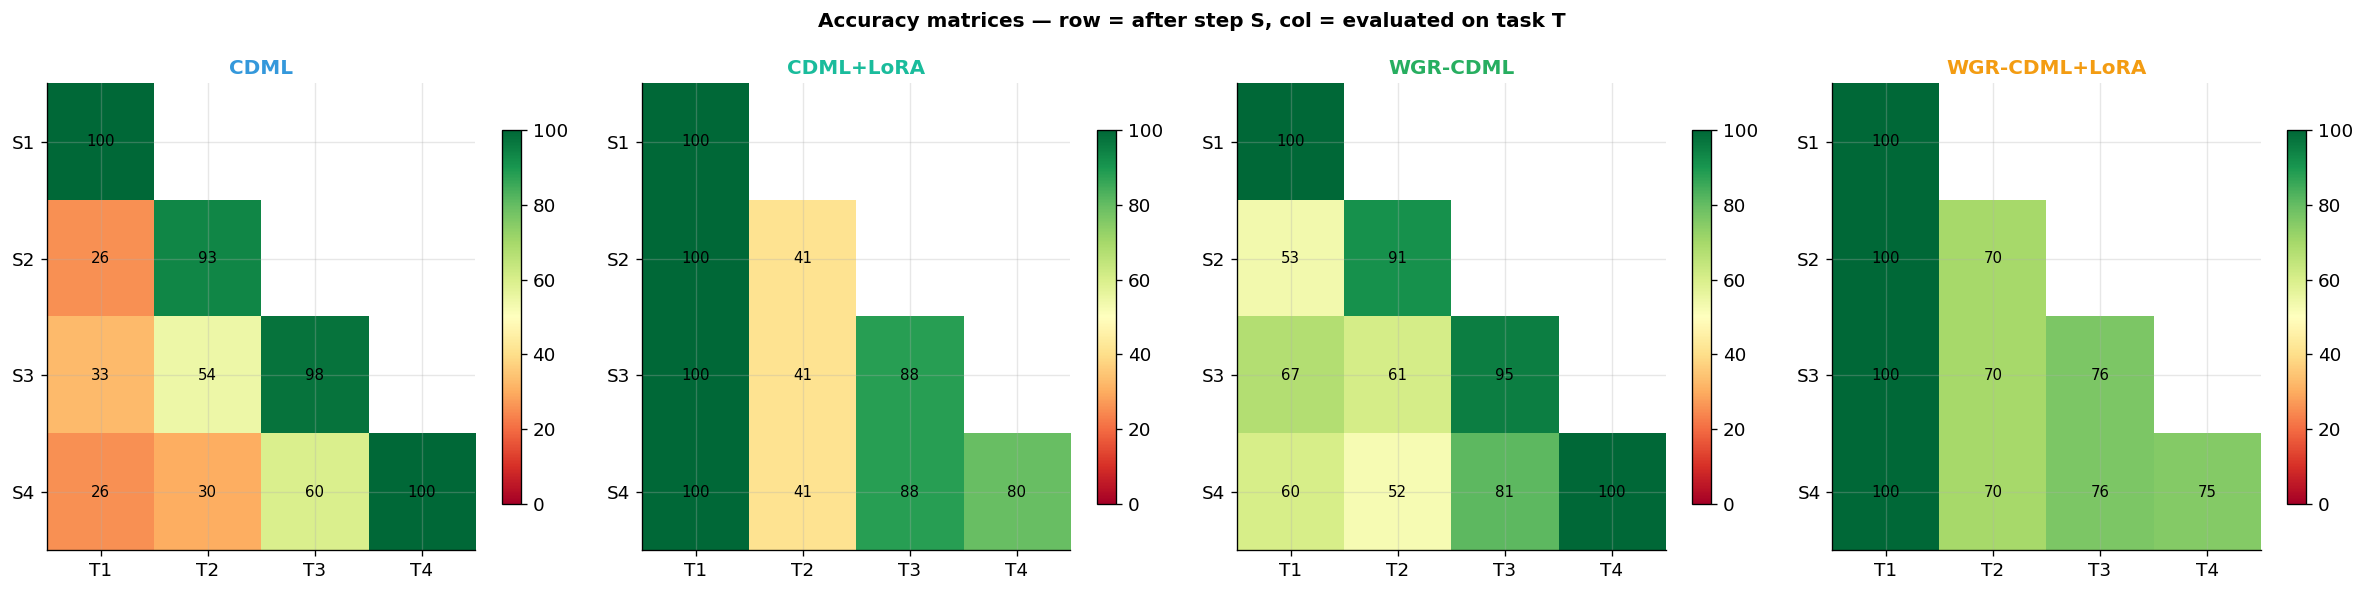

In [15]:
# ── Accuracy matrices ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (label, _, mat, _, _, color) in zip(axes, MODEL_REGISTRY):
    masked = np.ma.masked_invalid(mat * 100)
    im = ax.imshow(masked, cmap='RdYlGn', vmin=0, vmax=100, aspect='auto')
    plt.colorbar(im, ax=ax, shrink=0.8)
    ax.set_xticks(range(n_tasks)); ax.set_yticks(range(n_tasks))
    ax.set_xticklabels([f'T{i+1}' for i in range(n_tasks)])
    ax.set_yticklabels([f'S{i+1}' for i in range(n_tasks)])
    ax.set_title(label, color=color, fontsize=12, fontweight='bold')
    for i in range(n_tasks):
        for j in range(n_tasks):
            if not np.isnan(mat[i, j]):
                v = mat[i, j] * 100
                ax.text(j, i, f'{v:.0f}', ha='center', va='center',
                        fontsize=9, color='k' if v > 20 else 'w')

fig.suptitle('Accuracy matrices — row = after step S, col = evaluated on task T',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_accuracy_matrices.png', bbox_inches='tight')
plt.show()

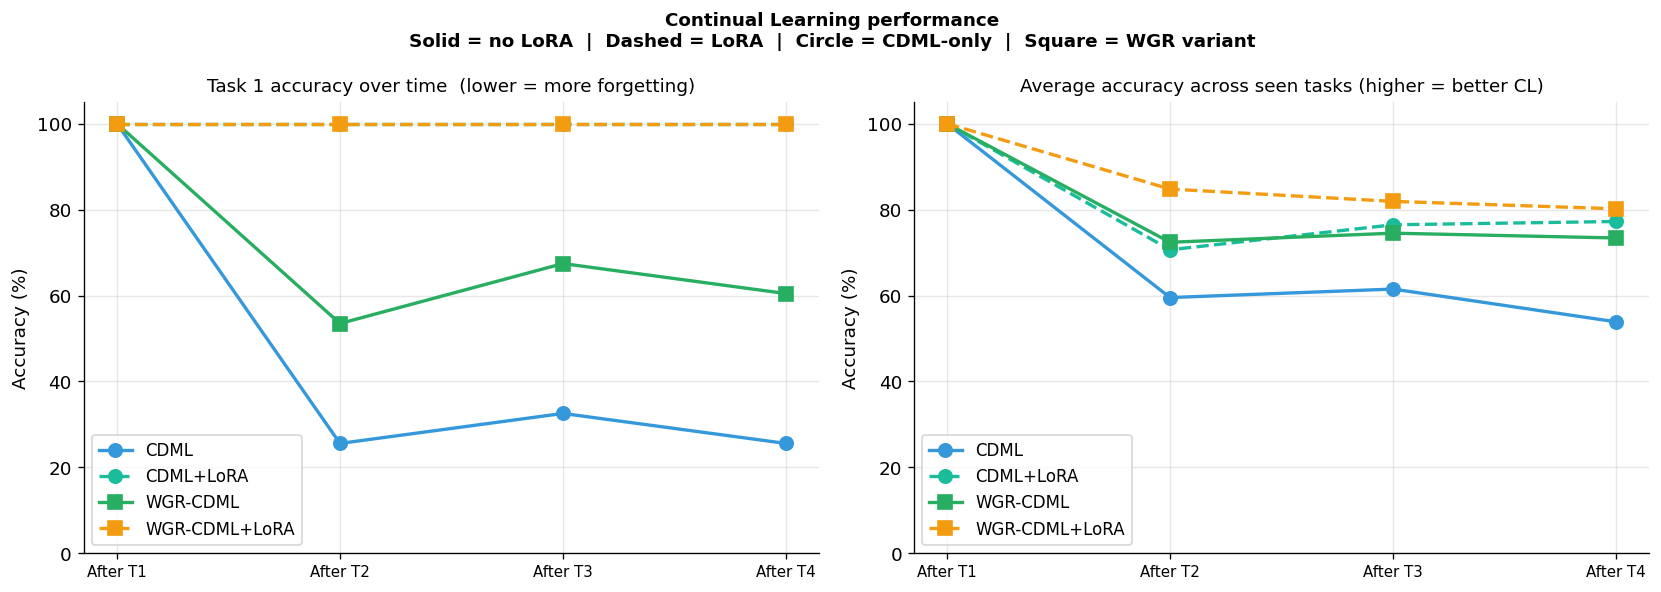

In [16]:
# ── Forgetting curves ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
steps = list(range(1, n_tasks + 1))

for label, _, mat, _, _, color in MODEL_REGISTRY:
    ls   = '--' if 'LoRA' in label else '-'
    mark = 's' if 'WGR' in label else 'o'
    t1_vals  = [mat[s, 0]*100 for s in range(n_tasks) if not np.isnan(mat[s, 0])]
    avg_vals = [np.nanmean(mat[s, :s+1])*100 for s in range(n_tasks)]
    axes[0].plot(steps[:len(t1_vals)], t1_vals,
                 color=color, lw=2, ls=ls, marker=mark, ms=8, label=label)
    axes[1].plot(steps, avg_vals,
                 color=color, lw=2, ls=ls, marker=mark, ms=8, label=label)

for ax, title in [
    (axes[0], 'Task 1 accuracy over time  (lower = more forgetting)'),
    (axes[1], 'Average accuracy across seen tasks (higher = better CL)')]:
    ax.set_xticks(steps)
    ax.set_xticklabels([f'After T{s}' for s in steps], fontsize=9)
    ax.set_ylim(0, 105); ax.set_ylabel('Accuracy (%)')
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=10)

plt.suptitle('Continual Learning performance\n'             'Solid = no LoRA  |  Dashed = LoRA  |  Circle = CDML-only  |  Square = WGR variant',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_forgetting_curves.png', bbox_inches='tight')
plt.show()

In [17]:
# ── LoRA parameter footprint per task ────────────────────────────────────────
print('── Parameter footprint analysis ──')
for label, model, *_ in MODEL_REGISTRY:
    total_p = sum(p.numel() for p in model.parameters())
    if hasattr(model, 'lora_parameters'):
        lora_p  = sum(p.numel() for p in model.lora_parameters())
        base_p  = total_p - lora_p
        print(f'  {label:<18}  total={total_p:>8,}  '
              f'base={base_p:>8,}  '
              f'LoRA/task={lora_p:>6,}  '
              f'({lora_p*4} bytes/task)')
    else:
        print(f'  {label:<18}  total={total_p:>8,}  (no LoRA)')

── Parameter footprint analysis ──
  CDML                total= 284,115  (no LoRA)
  CDML+LoRA           total= 313,603  base= 284,115  LoRA/task=29,488  (117952 bytes/task)
  WGR-CDML            total= 284,115  (no LoRA)
  WGR-CDML+LoRA       total= 313,603  base= 284,115  LoRA/task=29,488  (117952 bytes/task)


## 7b. Attack A₂ — Membership Inference Attack (MIA)

**Goal:** Given a gait window (x, y), determine whether that specific sample was part of the model's training data.

**Protocol:** Threshold-based MIA (Yeom et al., 2018).  
Score function: `s(x, y) = −CE(f(x), y)` — lower loss → model memorised the sample → more likely member.

**Members vs non-members:** Training windows vs test windows from the **same task and same subjects** (hardest setting — same distribution, only window identity differs).

**LoRA note:** For LoRA models, the per-task adapter is loaded before scoring, matching the oracle IIA convention.

**CDML attacker modes:**
- **no-seed (realistic):** attacker zeros the modulation sequence — loss inflated equally for all inputs, collapsing member/non-member separation.
- **oracle (upper bound):** attacker knows the seed and sets the correct sequence before scoring.

**Metric:** AUC of the binary classifier induced by the score threshold. 50% = random guess (perfect privacy).


In [15]:
def run_mia(model, task_data, task_names, device, is_lora=False,
            cdml_mode='none', n_samples=200):
    """
    Threshold-based MIA (Yeom et al. 2018).
    Members   = randomly sampled training windows for the task.
    Non-members = randomly sampled test windows from the same task
                  (same subjects, unseen windows — hardest setting).
    cdml_mode: 'oracle' | 'no_seed'
    Returns: {task_name: {auc, eer, fpr, tpr, m_scores, nm_scores}}
    """
    results = {}
    for t_idx, task_name in enumerate(task_names):

        if cdml_mode == 'oracle':
            model.set_task_sequence(task_name, CDML_SEED_BASE + t_idx)
        elif cdml_mode == 'no_seed':
            model.zero_sequence()
        if is_lora:
            model.load_lora(task_name)

        train_ds = task_data[task_name]['train']
        test_ds  = task_data[task_name]['test']

        rng     = np.random.default_rng(RANDOM_SEED + 77 + t_idx)
        n_mem   = min(n_samples, len(train_ds))
        n_non   = min(n_samples, len(test_ds))
        mem_idx = rng.choice(len(train_ds), n_mem, replace=False)
        non_idx = rng.choice(len(test_ds),  n_non, replace=False)

        model.eval()
        with torch.no_grad():
            X_mem = torch.stack([train_ds[int(i)][0] for i in mem_idx]).to(device)
            y_mem = torch.stack([train_ds[int(i)][1] for i in mem_idx]).to(device)
            losses_mem = nn.CrossEntropyLoss(reduction='none')(
                model(X_mem), y_mem).cpu().float().numpy()

            X_non = torch.stack([test_ds[int(i)][0] for i in non_idx]).to(device)
            y_non = torch.stack([test_ds[int(i)][1] for i in non_idx]).to(device)
            losses_non = nn.CrossEntropyLoss(reduction='none')(
                model(X_non), y_non).cpu().float().numpy()

        m_arr  = -losses_mem    # higher = lower loss = more likely member
        nm_arr = -losses_non

        scores = np.concatenate([m_arr, nm_arr])
        labels = np.concatenate([np.ones(len(m_arr)), np.zeros(len(nm_arr))])
        fpr, tpr, _ = roc_curve(labels, scores)
        roc_auc     = sk_auc(fpr, tpr)
        fnr         = 1 - tpr
        eer_idx     = np.nanargmin(np.abs(fpr - fnr))
        eer         = float(np.mean([fpr[eer_idx], fnr[eer_idx]]))

        results[task_name] = {
            'auc':       roc_auc,
            'eer':       eer,
            'fpr':       fpr,
            'tpr':       tpr,
            'm_scores':  m_arr,
            'nm_scores': nm_arr,
        }
    return results


print('Running MIA on all models...')
mia_results = {}

for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    print(f'  {label} (no-seed)...')
    mia_results[f'{label} (no-seed)'] = run_mia(
        model, task_data, task_names, DEVICE,
        is_lora=is_lora, cdml_mode='no_seed')
    print(f'  {label} (oracle)...')
    mia_results[f'{label} (oracle)'] = run_mia(
        model, task_data, task_names, DEVICE,
        is_lora=is_lora, cdml_mode='oracle')

# Restore sequences and adapters
for label, model, _, is_cdml, is_lora, _ in MODEL_REGISTRY:
    model.set_task_sequence('Task 4', CDML_SEED_BASE + 3)
    if is_lora: model.load_lora('Task 4')

print('MIA complete.')


Running MIA on all models...
  CDML (no-seed)...
  CDML (oracle)...
  CDML+LoRA (no-seed)...
  CDML+LoRA (oracle)...
  WGR-CDML (no-seed)...
  WGR-CDML (oracle)...
  WGR-CDML+LoRA (no-seed)...
  WGR-CDML+LoRA (oracle)...
MIA complete.


── MIA AUC per task (50% = random / ideal) ──
  Model                        |   Task 1 |   Task 2 |   Task 3 |   Task 4 | Avg
  ────────────────────────────────────────────────────────────────────────────────
  CDML (no-seed)               |    50.1% |    49.3% |    50.1% |    50.3% |  49.9%
  CDML (oracle)                |    50.3% |    52.8% |    55.2% |    56.1% |  53.6%
  CDML+LoRA (no-seed)          |    49.8% |    51.1% |    51.7% |    49.9% |  50.6%
  CDML+LoRA (oracle)           |    56.4% |    54.6% |    52.0% |    50.4% |  53.3%
  WGR-CDML (no-seed)           |    50.2% |    49.4% |    50.4% |    50.4% |  50.1%
  WGR-CDML (oracle)            |    52.8% |    55.0% |    51.7% |    61.6% |  55.3%
  WGR-CDML+LoRA (no-seed)      |    49.8% |    51.1% |    51.7% |    49.9% |  50.6%
  WGR-CDML+LoRA (oracle)       |    56.4% |    54.0% |    52.4% |    51.7% |  53.6%

── MIA EER per task (50% = random / ideal) ──
  Model                        |   Task 1 |   Task 2 |   Task 3 |   Tas

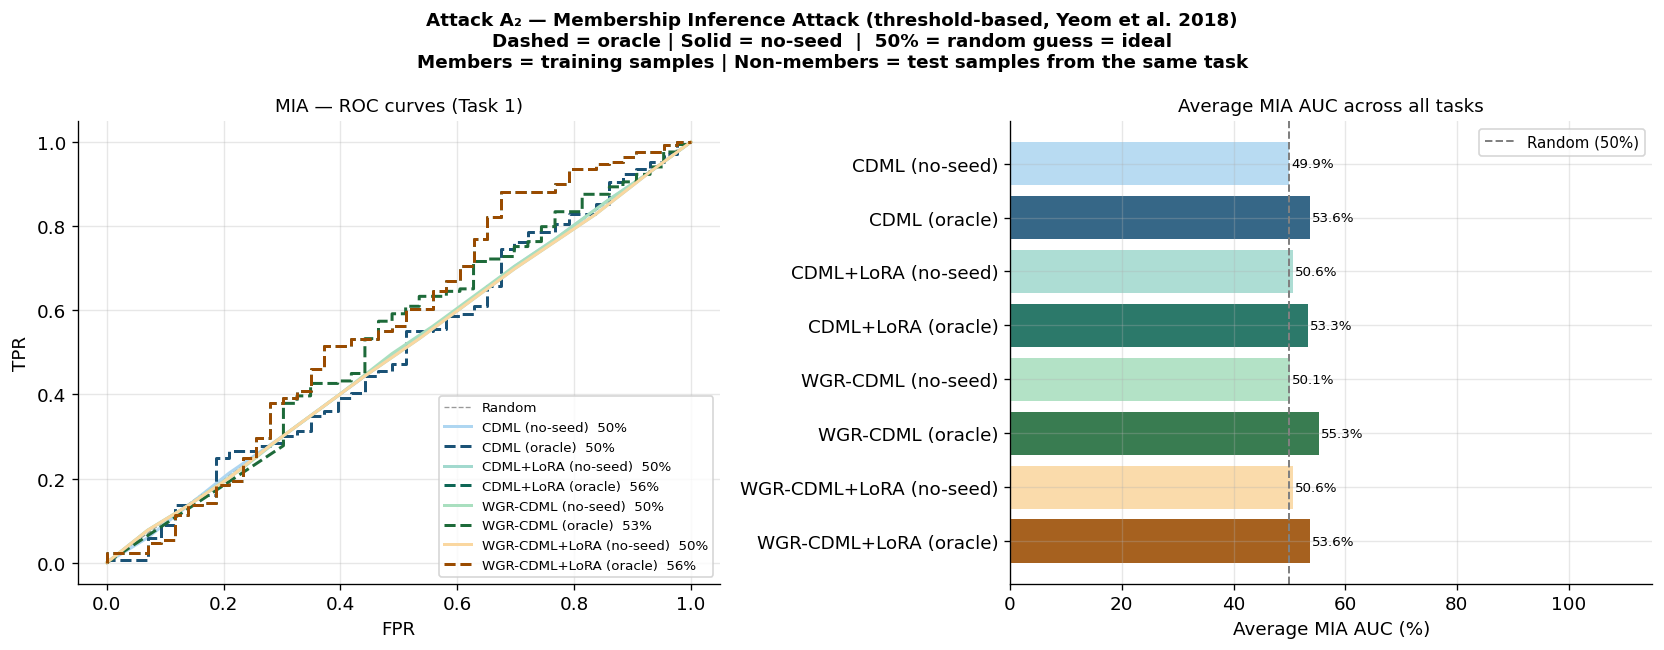

In [16]:
# ── MIA results table ─────────────────────────────────────────────────────────
print('── MIA AUC per task (50% = random / ideal) ──')
print(f'  {"Model":<28} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]) + ' | Avg')
print('  ' + '─' * 80)
for key, res in mia_results.items():
    aucs = [res[t]['auc'] * 100 for t in task_names]
    print(f'  {key:<28} | ' +
          ' | '.join([f'{a:>7.1f}%' for a in aucs]) +
          f' | {np.mean(aucs):>5.1f}%')

print()
print('── MIA EER per task (50% = random / ideal) ──')
print(f'  {"Model":<28} | ' +
      ' | '.join([f'{t:>8}' for t in task_names]) + ' | Avg')
print('  ' + '─' * 80)
for key, res in mia_results.items():
    eers = [res[t]['eer'] * 100 for t in task_names]
    print(f'  {key:<28} | ' +
          ' | '.join([f'{e:>7.1f}%' for e in eers]) +
          f' | {np.mean(eers):>5.1f}%')

# ── Colour map (mirrors IIA_COLORS) ──────────────────────────────────────────
MIA_COLORS = {
    'CDML (no-seed)':          '#AED6F1', 'CDML (oracle)':          '#1A5276',
    'CDML+LoRA (no-seed)':     '#A2D9CE', 'CDML+LoRA (oracle)':     '#0E6655',
    'WGR-CDML (no-seed)':      '#A9DFBF', 'WGR-CDML (oracle)':      '#1D6A39',
    'WGR-CDML+LoRA (no-seed)': '#FAD7A0', 'WGR-CDML+LoRA (oracle)': '#9A4B00',
}

FOCUS_TASK_MIA = 'Task 1'
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# ── ROC curves ────────────────────────────────────────────────────────────────
ax = axes[0]
ax.plot([0, 1], [0, 1], 'k--', lw=0.8, alpha=0.4, label='Random')
for key, res in mia_results.items():
    fpr, tpr = res[FOCUS_TASK_MIA]['fpr'], res[FOCUS_TASK_MIA]['tpr']
    ls = '--' if 'oracle' in key else '-'
    ax.plot(fpr, tpr, color=MIA_COLORS.get(key, '#888'), lw=1.8, ls=ls,
            label=f'{key}  {res[FOCUS_TASK_MIA]["auc"] * 100:.0f}%')
ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
ax.set_title(f'MIA — ROC curves ({FOCUS_TASK_MIA})', fontsize=11)
ax.legend(fontsize=8, loc='lower right')

# ── Average AUC bar chart ─────────────────────────────────────────────────────
ax2 = axes[1]
mia_keys  = list(mia_results.keys())
mia_avgs  = [np.mean([mia_results[k][t]['auc'] * 100 for t in task_names])
             for k in mia_keys]
bars = ax2.barh(mia_keys[::-1], mia_avgs[::-1],
                color=[MIA_COLORS.get(k, '#888') for k in mia_keys[::-1]], alpha=0.88)
ax2.axvline(50, color='gray', ls='--', lw=1.2, label='Random (50%)')
for bar in bars:
    ax2.text(bar.get_width() + 0.4, bar.get_y() + bar.get_height() / 2,
             f'{bar.get_width():.1f}%', va='center', fontsize=8)
ax2.set_xlabel('Average MIA AUC (%)')
ax2.set_title('Average MIA AUC across all tasks', fontsize=11)
ax2.set_xlim(0, 115); ax2.legend(fontsize=9)

plt.suptitle(
    'Attack A\u2082 \u2014 Membership Inference Attack (threshold-based, Yeom et al. 2018)\n'
    'Dashed = oracle | Solid = no-seed  |  50% = random guess = ideal\n'
    'Members = training samples | Non-members = test samples from the same task',
    fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig('fig_lora_mia.png', bbox_inches='tight')
plt.show()
